

# Download Stock Data F25
### OPIM 5641 — Business Decision Modeling · Module4

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5641-notebooks/blob/main/Module4/DownloadStockData_F25.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Download Stock Market Data!
Now let's pull down some stock data as an example.

In [33]:
# some useful modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install yfinance
import yfinance as yf

In [34]:
tickers_list = ['NFLX','IBM','GE','GOOG','AAPL','KO','AMZN','HD','NKE','WMT','BTC-USD']

start = "2022-09-01"
end   = "2025-11-04" # today!

dow_prices = {}
for t in tickers_list:
    try:
        df = yf.download(t, start=start, end=end, interval="1d", progress=False, auto_adjust=False)
        if not df.empty:
            dow_prices[t] = df
        else:
            print(f"Warning: no data returned for {t}")
    except Exception as e:
        print(f"Failed {t}: {e}")

# take a peak!
dow_prices

{'NFLX': Price         Adj Close        Close         High          Low         Open  \
 Ticker             NFLX         NFLX         NFLX         NFLX         NFLX   
 Date                                                                          
 2022-09-01   230.039993   230.039993   230.369995   219.470001   220.720001   
 2022-09-02   226.110001   226.110001   233.880005   225.039993   231.029999   
 2022-09-06   218.389999   218.389999   226.850006   214.690002   225.589996   
 2022-09-07   228.960007   228.960007   229.330002   218.270004   220.210007   
 2022-09-08   227.440002   227.440002   228.740005   221.300003   224.160004   
 ...                 ...          ...          ...          ...          ...   
 2025-10-28  1102.500000  1102.500000  1116.979980  1093.010010  1094.000000   
 2025-10-29  1100.410034  1100.410034  1108.550049  1096.000000  1099.839966   
 2025-10-30  1089.000000  1089.000000  1106.160034  1088.109985  1094.400024   
 2025-10-31  1118.859985  1118.8

In [35]:
# # some stock-specific packages
# !pip install requests_html
# !pip install yahoo_fin
# import yahoo_fin.stock_info as si

In [36]:
# # Assign the ticker list that we want to scrap
# tickers_list = ['NFLX','IBM','GE','GOOG','AAPL','KO','AMZN','HD','NKE','WMT','BTC-USD']
# # pull historical price data for each stocks to match with our news score later
# dow_prices = {ticker : si.get_data(ticker,start_date = '12/27/2017',end_date='01/22/2020',interval='1d') for ticker in tickers_list}

In [37]:
# let's extract just the data we need (adjclose)
# get the adjclose price for the NFLX (one sample)\
# update this to the name of your first stock...
prep_data = pd.DataFrame(dow_prices['NFLX']['Adj Close']).rename(columns = {"Adj Close":"NFLX"})

# combine all the tickers (all the rest of the samples)
for i in tickers_list[1:]:
  prep_data[i] = pd.DataFrame(dow_prices[i]['Adj Close'])
prep_data

Ticker,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Date,,,,,,,,,,,
2022-09-01,230.039993,115.476768,44.792408,109.798622,155.505310,56.237255,127.820000,271.939423,101.029366,43.142033,20127.140625
2022-09-02,226.110001,113.811310,44.394005,107.941330,153.388672,55.466255,127.510002,270.576752,100.605965,42.667252,19969.771484
2022-09-06,218.389999,112.858376,44.228527,106.749496,152.128586,55.493465,126.110001,268.389221,100.044609,42.455513,18837.667969
2022-09-07,228.960007,113.740067,45.098873,109.729103,153.536346,56.518436,129.479996,275.739899,103.212914,43.546246,19290.324219
2022-09-08,227.440002,114.416939,45.215321,108.676300,152.059677,56.346092,129.820007,277.992401,103.450790,43.767605,19329.833984
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-28,1102.500000,312.570007,309.790009,268.429993,269.000000,70.160004,229.250000,385.750000,67.430000,103.169998,112956.164062
2025-10-29,1100.410034,308.209991,314.279999,275.170013,269.700012,68.349998,230.300003,378.040009,65.349998,102.459999,110055.304688
2025-10-30,1089.000000,310.059998,310.750000,281.899994,271.399994,68.980003,222.860001,379.549988,64.900002,102.230003,108305.546875


In [38]:
prep_data.shape

(796, 11)

Rather than use the raw time series, let's build a model based on past returns (the difference from the previous day).

In [39]:
# create return features for each ticker,
# we will just use a pct_change as the return
return_data = pd.DataFrame()
for i in tickers_list:
  return_data[i] = prep_data[i].pct_change()
# drop the na records
return_data.dropna(inplace=True)
return_data

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Date,,,,,,,,,,,
2022-09-02,-0.017084,-0.014422,-0.008894,-0.016915,-0.013611,-0.013710,-0.002425,-0.005011,-0.004191,-0.011005,-0.007819
2022-09-06,-0.034143,-0.008373,-0.003727,-0.011041,-0.008215,0.000491,-0.010980,-0.008085,-0.005580,-0.004963,-0.056691
2022-09-07,0.048400,0.007812,0.019678,0.027912,0.009254,0.018470,0.026723,0.027388,0.031669,0.025691,0.024029
2022-09-08,-0.006639,0.005951,0.002582,-0.009595,-0.009618,-0.003049,0.002626,0.008169,0.002305,0.005083,0.002048
2022-09-09,0.026952,0.005604,0.003660,0.021568,0.018840,0.003220,0.026575,-0.000434,0.020601,0.003005,0.106122
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-28,0.007254,-0.001661,-0.009749,-0.005557,0.000707,0.001427,0.010045,0.001246,-0.016912,-0.012444,-0.010193
2025-10-29,-0.001896,-0.013949,0.014494,0.025109,0.002602,-0.025798,0.004580,-0.019987,-0.030847,-0.006882,-0.025681
2025-10-30,-0.010369,0.006002,-0.011232,0.024458,0.006303,0.009217,-0.032306,0.003994,-0.006886,-0.002245,-0.015899


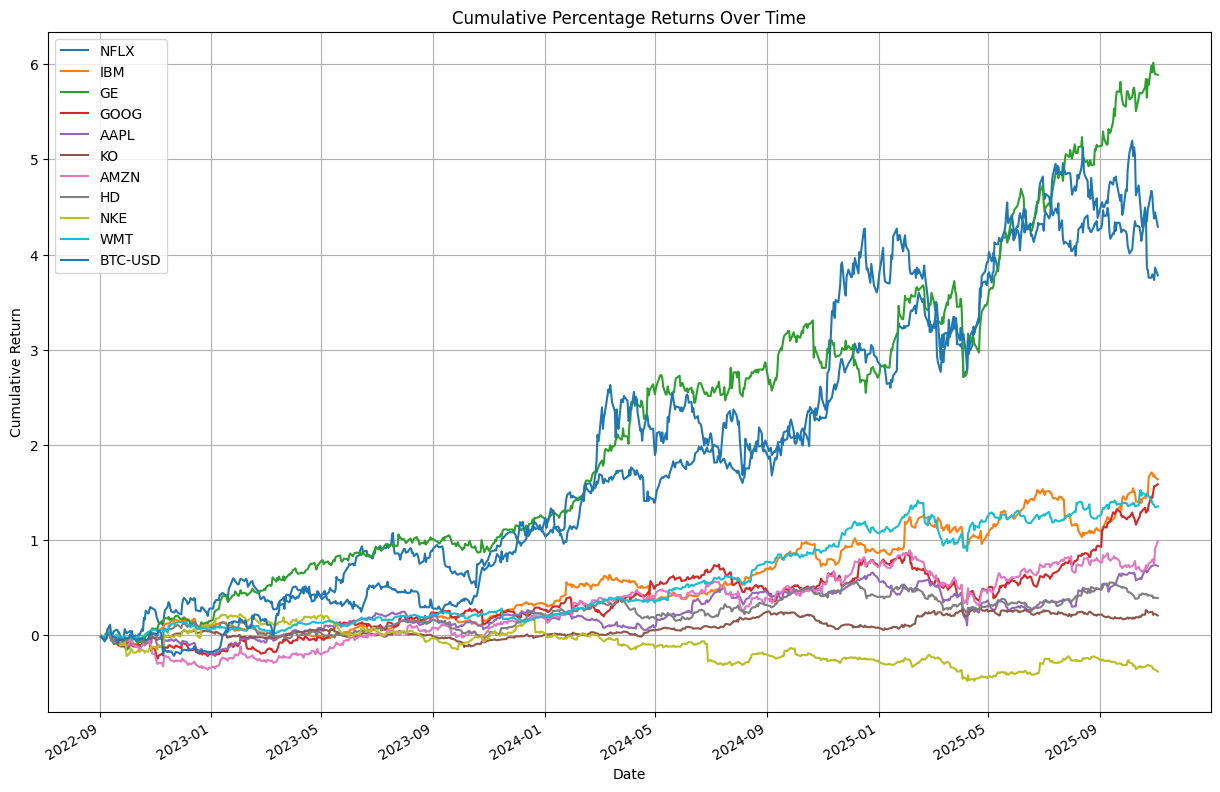

In [40]:
# Calculate cumulative returns for simple returns
cumulative_returns = (1 + return_data).cumprod() - 1

# Plot the cumulative returns
cumulative_returns.plot(figsize=(15, 10))
plt.title('Cumulative Percentage Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()

In [41]:
# Calculate log returns
log_return_data = pd.DataFrame()
for i in tickers_list:
  log_return_data[i] = np.log(prep_data[i] / prep_data[i].shift(1))

# Drop the na records
log_return_data.dropna(inplace=True)

print("Simple Returns (using pct_change):")
display(return_data.head())

print("\nLog Returns:")
display(log_return_data.head())

Simple Returns (using pct_change):


,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Date,,,,,,,,,,,
2022-09-02,-0.017084,-0.014422,-0.008894,-0.016915,-0.013611,-0.013710,-0.002425,-0.005011,-0.004191,-0.011005,-0.007819
2022-09-06,-0.034143,-0.008373,-0.003727,-0.011041,-0.008215,0.000491,-0.010980,-0.008085,-0.005580,-0.004963,-0.056691
2022-09-07,0.048400,0.007812,0.019678,0.027912,0.009254,0.018470,0.026723,0.027388,0.031669,0.025691,0.024029
2022-09-08,-0.006639,0.005951,0.002582,-0.009595,-0.009618,-0.003049,0.002626,0.008169,0.002305,0.005083,0.002048
2022-09-09,0.026952,0.005604,0.003660,0.021568,0.018840,0.003220,0.026575,-0.000434,0.020601,0.003005,0.106122



Log Returns:


,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Date,,,,,,,,,,,
2022-09-02,-0.017232,-0.014527,-0.008934,-0.017060,-0.013705,-0.013805,-0.002428,-0.005024,-0.004200,-0.011066,-0.007849
2022-09-06,-0.034739,-0.008408,-0.003734,-0.011103,-0.008249,0.000490,-0.011040,-0.008118,-0.005595,-0.004975,-0.058361
2022-09-07,0.047265,0.007782,0.019487,0.027530,0.009211,0.018302,0.026372,0.027020,0.031178,0.025367,0.023745
2022-09-08,-0.006661,0.005933,0.002579,-0.009641,-0.009664,-0.003054,0.002623,0.008136,0.002302,0.005070,0.002046
2022-09-09,0.026595,0.005589,0.003653,0.021339,0.018664,0.003214,0.026228,-0.000434,0.020392,0.003001,0.100860


In [42]:
return_data.shape

(795, 11)

# Visualize the Time Series

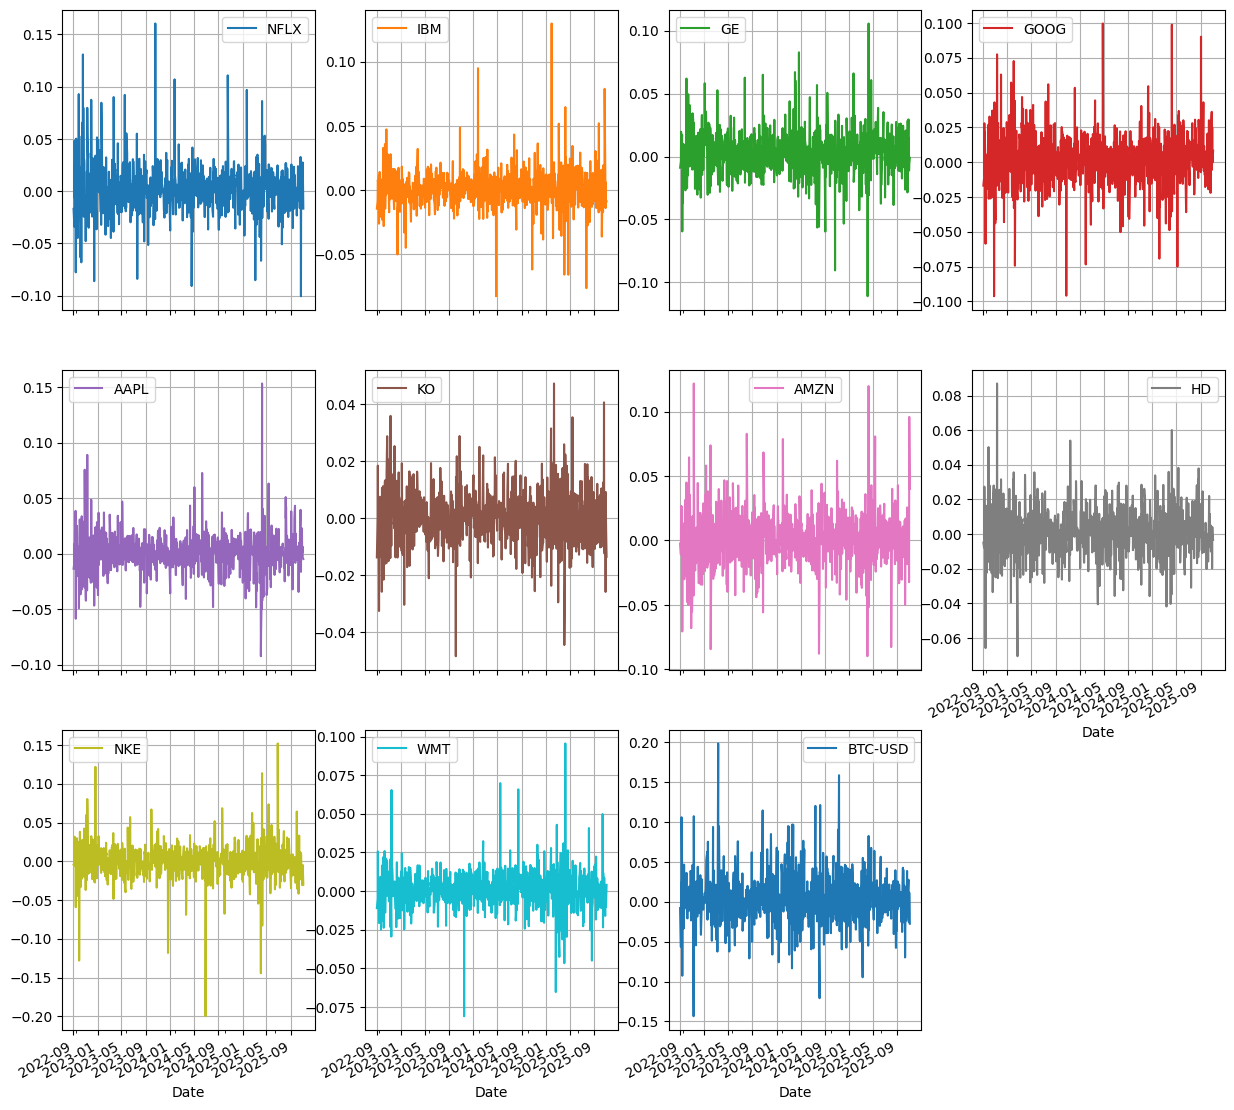

In [43]:
return_data.plot(subplots=True,
        grid=True,
        layout=(3,4),
         figsize=(15,15))
plt.show()

In [44]:
# Calculate monthly returns
monthly_returns = prep_data.resample('ME').ffill().pct_change()

# Drop the first row which will contain NaNs
monthly_returns.dropna(inplace=True)

print("Monthly Returns:")
display(monthly_returns)

Monthly Returns:


Ticker,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Date,,,,,,,,,,,
2022-10-31,0.239721,0.163959,0.256825,-0.015497,0.109552,0.068368,-0.093451,0.073168,0.115014,0.097378,0.054755
2022-11-30,0.046766,0.089560,0.104871,0.071730,-0.033028,0.070362,-0.057595,0.100699,0.183535,0.070892,-0.162336
2022-12-31,-0.034857,-0.053794,-0.024416,-0.125382,-0.122273,0.000000,-0.129894,-0.025093,0.070008,-0.066235,-0.032966
2023-01-31,0.200013,-0.043722,0.230396,0.125549,0.110521,-0.036001,0.227738,0.026309,0.088198,0.014669,0.393716
2023-02-28,-0.089668,-0.028515,0.052559,-0.095825,0.023183,-0.029517,-0.086299,-0.085233,-0.067070,-0.012094,0.000349
2023-03-31,0.072486,0.013844,0.129603,0.151717,0.118649,0.050341,0.096148,0.002418,0.035354,0.041683,0.230313
2023-04-30,-0.045010,-0.035701,0.035251,0.040577,0.028987,0.034177,0.020912,0.018365,0.033268,0.023873,0.030261
2023-05-31,0.197921,0.031116,0.025866,0.139993,0.046058,-0.069992,0.143480,-0.050074,-0.169350,-0.023462,-0.072276
2023-06-30,0.114516,0.040594,0.081947,-0.019454,0.094330,0.017074,0.081108,0.095925,0.051998,0.070198,0.119678


<Axes: xlabel='Date'>

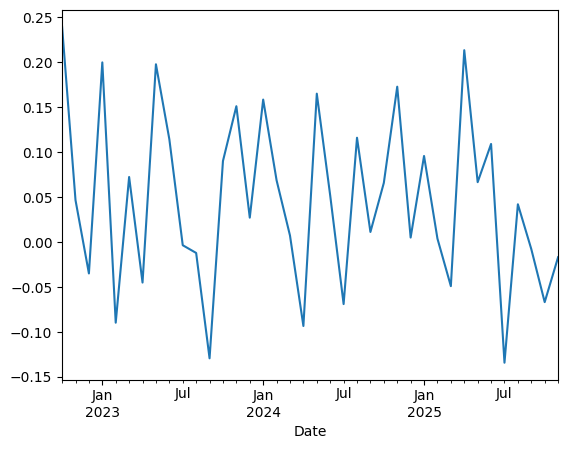

In [45]:
monthly_returns['NFLX'].plot()

<Axes: xlabel='Date'>

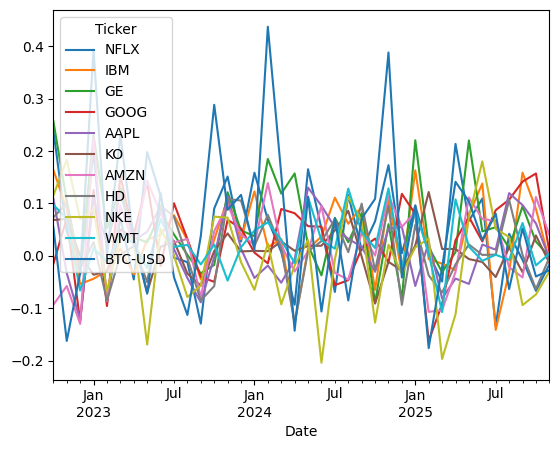

In [46]:
monthly_returns.plot()

In [47]:
monthly_returns.mean()

,0
Ticker,
NFLX,0.045891
IBM,0.030997
GE,0.059857
GOOG,0.032107
AAPL,0.020176
KO,0.008355
AMZN,0.024674
HD,0.012365
NKE,-0.001794


In [48]:
monthly_returns.cov()

Ticker,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,WMT,BTC-USD
Ticker,,,,,,,,,,,
NFLX,0.009639,0.003166,0.002516,0.001070,0.002250,0.000452,0.002881,0.002433,0.001862,0.002694,0.005457
IBM,0.003166,0.005799,0.002318,0.000480,0.000977,0.001044,0.000784,0.002500,0.001519,0.001553,0.000799
GE,0.002516,0.002318,0.007121,0.001617,0.001042,0.000918,0.002118,0.002183,0.003478,0.001400,0.004627
GOOG,0.001070,0.000480,0.001617,0.006167,0.001989,-0.000803,0.003755,0.000557,-0.000635,0.000307,0.000800
AAPL,0.002250,0.000977,0.001042,0.001989,0.004313,0.000564,0.001800,0.001285,0.001008,0.000834,0.001271
KO,0.000452,0.001044,0.000918,-0.000803,0.000564,0.001790,-0.000955,0.000835,0.001547,0.000578,-0.001297
AMZN,0.002881,0.000784,0.002118,0.003755,0.001800,-0.000955,0.006572,0.001344,0.000345,0.000498,0.006260
HD,0.002433,0.002500,0.002183,0.000557,0.001285,0.000835,0.001344,0.004134,0.002527,0.001448,0.002722
NKE,0.001862,0.001519,0.003478,-0.000635,0.001008,0.001547,0.000345,0.002527,0.008621,0.001300,0.002295


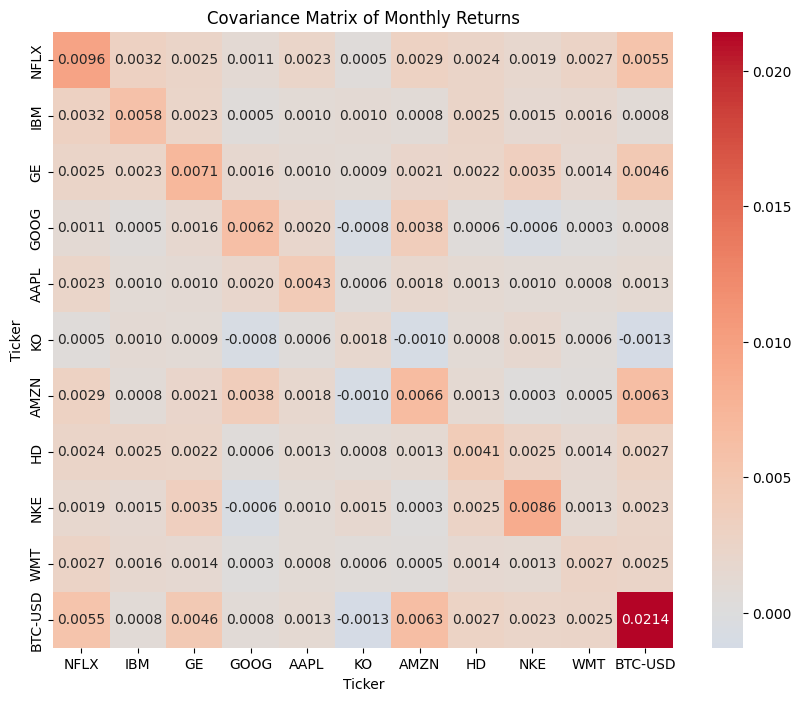

In [49]:
# Calculate the covariance matrix
cov_matrix = monthly_returns.cov()

# Plot the covariance matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, cmap='coolwarm', fmt=".4f", center=0)
plt.title('Covariance Matrix of Monthly Returns')
plt.show()

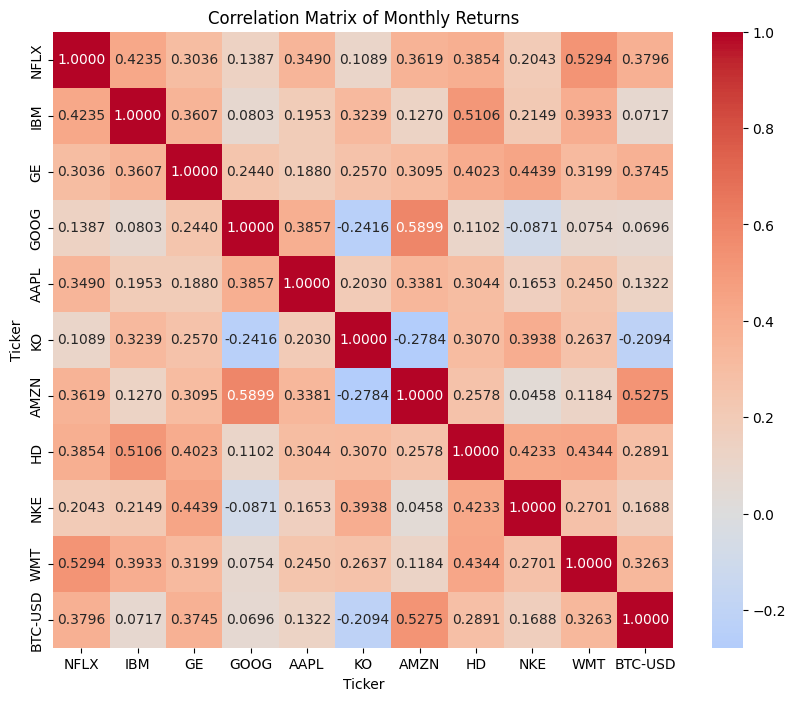

In [50]:
# Calculate the covariance matrix
cor_matrix = monthly_returns.corr()

# Plot the covariance matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".4f", center=0)
plt.title('Correlation Matrix of Monthly Returns')
plt.show()

In [51]:
monthly_returns.shape

(38, 11)

In [52]:
# look left, it should dump out... click Folder Icon
monthly_returns.to_csv('mydata.csv')

# Information about stocks

You can get some other interesting information about a particular stock using other libraries, such as yfinance (https://pypi.org/project/yfinance/):

In [53]:
apple = yf.Ticker("AAPL")
print(apple.info.keys())
print("Total revenue",apple.info["totalRevenue"])

dict_keys(['address1', 'city', 'state', 'zip', 'country', 'phone', 'website', 'industry', 'industryKey', 'industryDisp', 'sector', 'sectorKey', 'sectorDisp', 'longBusinessSummary', 'fullTimeEmployees', 'companyOfficers', 'auditRisk', 'boardRisk', 'compensationRisk', 'shareHolderRightsRisk', 'overallRisk', 'governanceEpochDate', 'compensationAsOfEpochDate', 'irWebsite', 'executiveTeam', 'maxAge', 'priceHint', 'previousClose', 'open', 'dayLow', 'dayHigh', 'regularMarketPreviousClose', 'regularMarketOpen', 'regularMarketDayLow', 'regularMarketDayHigh', 'dividendRate', 'dividendYield', 'exDividendDate', 'payoutRatio', 'fiveYearAvgDividendYield', 'beta', 'trailingPE', 'forwardPE', 'volume', 'regularMarketVolume', 'averageVolume', 'averageVolume10days', 'averageDailyVolume10Day', 'bid', 'ask', 'bidSize', 'askSize', 'marketCap', 'fiftyTwoWeekLow', 'fiftyTwoWeekHigh', 'allTimeHigh', 'allTimeLow', 'priceToSalesTrailing12Months', 'fiftyDayAverage', 'twoHundredDayAverage', 'trailingAnnualDividend

# On Your Own
Go try to run this on the Ms. Womack example.

Make a plot that shows the cumulative percentage returns over time (hint: use Pandas!).